<a href="https://colab.research.google.com/github/karaage0703/karaage-ai-book/blob/master/ch04/04_karaage_ai_book_gan_trainer_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GANを使って手の形の画像を生成する方法

## 教師データのダウンロード

ジャンケンの手の形の教師データをGitHubからダウンロード（Clone）します。

2,3行目はダウンロードしたデータから、使用するデータ以外の不要なファイルを削除しています。

In [ ]:
!git clone https://github.com/karaage0703/janken_dataset datasets
!rm -rf /content/datasets/.git
!rm /content/datasets/LICENSE

Cloning into 'datasets'...
remote: Enumerating objects: 210, done.
remote: Total 210 (delta 0), reused 0 (delta 0), pack-reused 210 (from 1)
Receiving objects: 100% (210/210), 4.60 MiB | 20.46 MiB/s, done.
Resolving deltas: 100% (3/3), done.


## データの前処理（データ水増し）

画像生成の成功率を上げるために、データの前処理（データの水増し）を行います。

ただ、TensorFlow→PyTorchに変更し、モデル構造も変更したことで、データの水増しは無くても安定するようになり、水増しは無い方が画質的には良いかもしれません。

データの前処理のあり/無しで効果の違いを確認してみてください。

必要なライブラリをインポート

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

データ水増し用のディレクトリを定義

In [ ]:
train_aug_dir = 'datasets'

データ水増しの関数定義

In [ ]:
# ヒストグラム均一化 (OpenCV to PyTorch)
def equalize_hist_rgb(img):
    img_yuv = img.convert('YCbCr')
    y, cb, cr = img_yuv.split()
    y = y.point(lambda i: i * 255 / max(y.histogram()))
    return Image.merge('YCbCr', (y, cb, cr)).convert('RGB')

# ガウシアンノイズ追加
def add_gaussian_noise(img, mean=0, std=15):
    img_array = np.array(img)
    noise = np.random.normal(mean, std, img_array.shape)
    noisy_img = img_array + noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy_img)

# Salt & Pepperノイズ追加
def add_salt_pepper_noise(img, salt_prob=0.004, pepper_prob=0.004):
    img_array = np.array(img)
    salt_mask = np.random.rand(*img_array.shape[:2]) < salt_prob
    pepper_mask = np.random.rand(*img_array.shape[:2]) < pepper_prob
    img_array[salt_mask] = 255
    img_array[pepper_mask] = 0
    return Image.fromarray(img_array)

# データ前処理と水増し
def preprocess_and_augment_images(data_dir):
    image_files = []
    labels = os.listdir(data_dir)
    for label in labels:
        image_files.extend(glob.glob(os.path.join(data_dir, label, '*')))

    augmented_images = []
    for image_file in image_files:
        img = Image.open(image_file)
        augmented_images.append(img)
        augmented_images.append(equalize_hist_rgb(img))
        augmented_images.append(add_gaussian_noise(img))
        augmented_images.append(add_salt_pepper_noise(img))
        augmented_images.append(img.transpose(Image.FLIP_LEFT_RIGHT))

    return augmented_images

データを水増し

In [ ]:
augmented_images = preprocess_and_augment_images(train_aug_dir)

水増ししたデータの確認

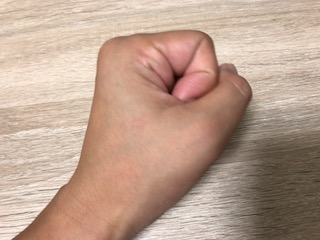

In [ ]:
augmented_images[0]

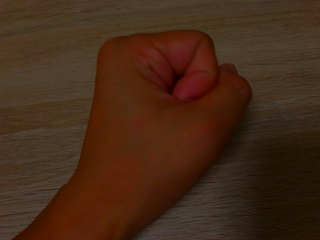

In [ ]:
augmented_images[1]

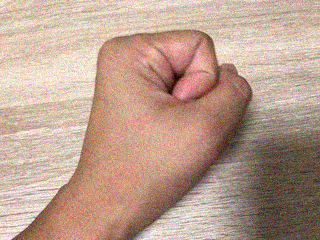

In [ ]:
augmented_images[2]

## GANのモデルの学習

### 学習の事前準備

最初にGANの学習やテストに必要な関数を定義しておきます

教師データのディレクトリから画像を読み込んでひとまとまり（バッチ）にする関数を定義します。

画像認識の場合は、データの変換をしてくれる便利な関数がありましたが、GANの場合はそのような便利な関数がないので、自分で頑張って変換をしていると理解してください。

やっていることは、ファイルを読み込んでPytorchで学習できるように画像のサイズや、値の範囲を調整しているだけです。

In [ ]:
# データローダーの設定
def image_batch(augmented_images, batch_size):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    selected_images = random.sample(augmented_images, batch_size)
    images = [transform(img) for img in selected_images]
    return torch.stack(images)

実際どのような動きをするのか試してみましょう。以下を実行すると25個分のデータがバッチとして読み込まれます。

形式は Tensor となります。

In [ ]:
test_images = image_batch(augmented_images=augmented_images, batch_size=25)
print(type(test_images))

<class 'torch.Tensor'>


試しに表示してみましょう。手の画像が表示されました。

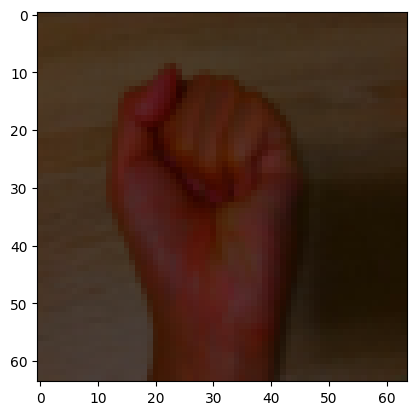

In [ ]:
plt.imshow(transforms.ToPILImage()(test_images[0] * 0.5 + 0.5))

次に、生成した画像をひとまとめにする関数を定義します。これは、複数の画像をまとめることでテスト結果をみやすくするものです。

ディープラーニングの学習とは直接関係ありませんが、このように結果の画像を見やすく加工することは、重要なテクニックなので使えるようにしておくと便利です。

In [ ]:
def combine_images(generated_images, cols=5, rows=5):
    shape = generated_images.shape
    h = shape[2]
    w = shape[3]
    image = np.zeros((rows * h, cols * w, 3))
    for index, img in enumerate(generated_images):
        if index >= cols * rows:
            break
        i = index // cols
        j = index % cols
        image[i * h:(i + 1) * h, j * w:(j + 1) * w, :] = img.permute(1, 2, 0).cpu().detach().numpy() * 0.5 + 0.5
    image = np.clip(image * 255, 0, 255).astype(np.uint8)
    return Image.fromarray(image)

では、さきほどバッチとして読み込んだ画像を結合してみましょう。

In [ ]:
test_combined_image = combine_images(test_images)

表示してみます。

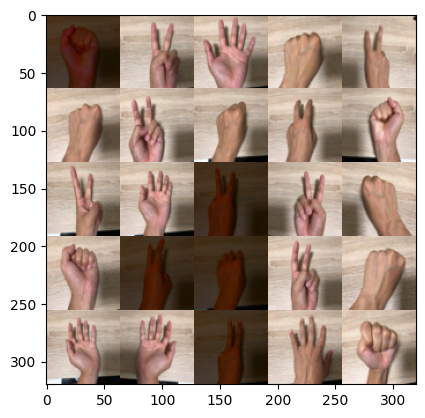

In [ ]:
plt.imshow(test_combined_image)

結合された画像が表示されましたね。

これで事前準備が完了したので、いよいよGANの学習をしていきます。

### GANの学習

ハイパーパラメータのセッティングをします。

In [ ]:
batch_size = 32
#epochs = 101
epochs = 501

その他、モデルの保存場所、生成した画像の保存場所、何世代毎に学習結果を確認するかを設定をします。

In [ ]:
model_dir = './model'
gen_images_dir = './gen_images'
each_step = 50

贋作者ネットワークの定義をします。

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 128 * 16 * 16),
            nn.BatchNorm1d(128 * 16 * 16),
            nn.ReLU(True),
            nn.Unflatten(1, (128, 16, 16)),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

鑑定士ネットワークの定義をします。

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

### モデルの学習

学習過程を保存するリストの準備と、生成した画像を保存するディレクトリを作成します。

In [ ]:
if not os.path.isdir(gen_images_dir):
    os.mkdir(gen_images_dir)

学習させる関数を定義します。

In [ ]:
def train_gan(generator, discriminator, augmented_images, epochs=1001, batch_size=32):
    criterion = nn.BCELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    g_loss_list = []
    d_loss_list = []

    for epoch in tqdm(range(epochs)):
        real_images = image_batch(augmented_images, batch_size)

        real_labels = torch.full((batch_size, 1), 0.9)  # 1を0.9に変更
        fake_labels = torch.full((batch_size, 1), 0.1)  # 0を0.1に変更

        # Discriminator学習
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, 100)
        fake_images = generator(noise)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        optimizer_d.zero_grad()
        d_loss.backward()

        # Discriminatorの勾配クリッピングを適用
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)

        optimizer_d.step()

        # Generator学習
        noise = torch.randn(batch_size, 100)
        fake_images = generator(noise)
        outputs = discriminator(fake_images)

        g_loss = criterion(outputs, real_labels)
        optimizer_g.zero_grad()
        g_loss.backward()

        # Generatorの勾配クリッピングを適用
        torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)

        optimizer_g.step()

        g_loss_list.append(g_loss.item())
        d_loss_list.append(d_loss.item())

        print(f'Epoch [{epoch}/{epochs}], d_loss: {d_loss.item()}, g_loss: {g_loss.item()}')

        if epoch % each_step == 0:
            # 生成された画像を表示して保存
            image = combine_images(fake_images)
            plt.ion()
            plt.imshow(image)
            plt.pause(0.001)

            image.save(f'./gen_images/gen_{epoch:05d}.png')

    # 学習ログを保存
    return g_loss_list, d_loss_list

学習します

  0%|          | 0/501 [00:00<?, ?it/s]

Epoch [0/501], d_loss: 1.4215196371078491, g_loss: 4.503894805908203


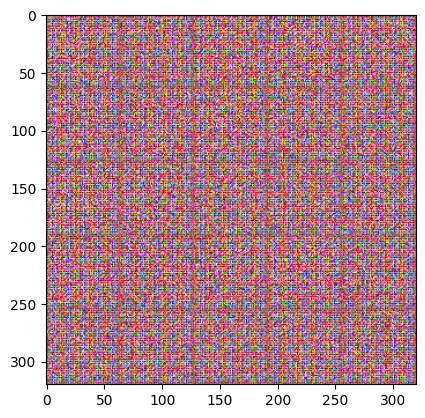

  0%|          | 2/501 [00:05<22:46,  2.74s/it]

Epoch [1/501], d_loss: 1.088249921798706, g_loss: 2.480748414993286


  1%|          | 3/501 [00:08<22:39,  2.73s/it]

Epoch [2/501], d_loss: 2.0478553771972656, g_loss: 0.3387545049190521


  1%|          | 4/501 [00:10<21:50,  2.64s/it]

...

Epoch [47/501], d_loss: 2.0164899826049805, g_loss: 4.28288459777832


 10%|▉         | 49/501 [01:59<17:19,  2.30s/it]

Epoch [48/501], d_loss: 1.0530903339385986, g_loss: 1.9924066066741943


 10%|▉         | 50/501 [02:02<18:08,  2.41s/it]

Epoch [49/501], d_loss: 0.8347148299217224, g_loss: 1.582543134689331
Epoch [50/501], d_loss: 0.8734322190284729, g_loss: 3.9266178607940674


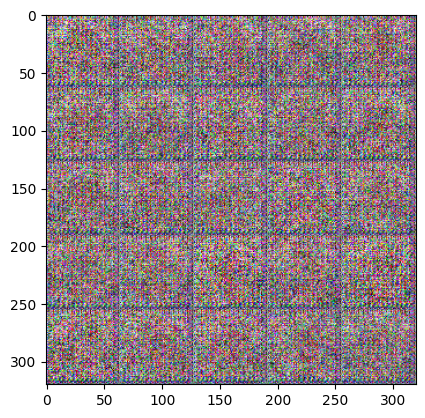

 10%|█         | 52/501 [02:07<18:36,  2.49s/it]

Epoch [51/501], d_loss: 1.0062330961227417, g_loss: 2.982550859451294


 11%|█         | 53/501 [02:09<18:08,  2.43s/it]

Epoch [52/501], d_loss: 0.6868737936019897, g_loss: 0.4420352578163147


 11%|█         | 54/501 [02:11<17:44,  2.38s/it]

...

Epoch [97/501], d_loss: 0.6869387626647949, g_loss: 4.811286926269531


 20%|█▉        | 99/501 [03:59<16:13,  2.42s/it]

Epoch [98/501], d_loss: 2.2139840126037598, g_loss: 3.9569125175476074


 20%|█▉        | 100/501 [04:01<15:49,  2.37s/it]

Epoch [99/501], d_loss: 1.457033634185791, g_loss: 2.0683858394622803
Epoch [100/501], d_loss: 0.69551682472229, g_loss: 1.2929192781448364


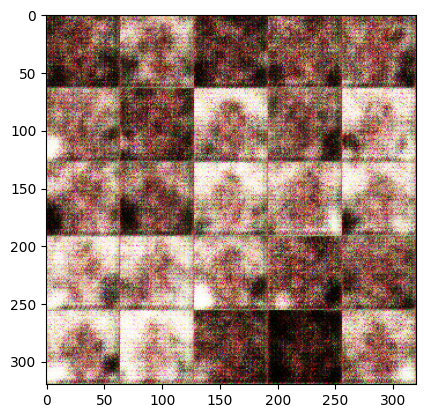

 20%|██        | 102/501 [04:06<15:57,  2.40s/it]

Epoch [101/501], d_loss: 1.2851605415344238, g_loss: 2.07403564453125


 21%|██        | 103/501 [04:09<16:53,  2.55s/it]

Epoch [102/501], d_loss: 0.6838524341583252, g_loss: 1.3419269323349


 21%|██        | 104/501 [04:11<16:20,  2.47s/it]

...

Epoch [147/501], d_loss: 0.8648853302001953, g_loss: 2.4508557319641113


 30%|██▉       | 149/501 [05:58<13:42,  2.34s/it]

Epoch [148/501], d_loss: 0.7773751020431519, g_loss: 1.676567792892456


 30%|██▉       | 150/501 [06:00<13:35,  2.32s/it]

Epoch [149/501], d_loss: 0.8139309883117676, g_loss: 3.112750291824341
Epoch [150/501], d_loss: 0.9746339321136475, g_loss: 1.972354769706726


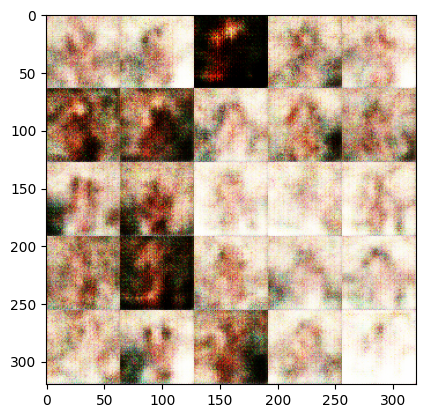

 30%|███       | 152/501 [06:06<14:56,  2.57s/it]

Epoch [151/501], d_loss: 0.8027536869049072, g_loss: 2.006300210952759


 31%|███       | 153/501 [06:08<14:21,  2.47s/it]

Epoch [152/501], d_loss: 0.7498637437820435, g_loss: 3.2212650775909424


 31%|███       | 154/501 [06:10<14:00,  2.42s/it]

...

Epoch [197/501], d_loss: 0.7928120493888855, g_loss: 2.4018640518188477


 40%|███▉      | 199/501 [07:59<12:24,  2.47s/it]

Epoch [198/501], d_loss: 0.798517107963562, g_loss: 1.391087293624878


 40%|███▉      | 200/501 [08:01<12:10,  2.43s/it]

Epoch [199/501], d_loss: 0.9544880390167236, g_loss: 2.3625032901763916
Epoch [200/501], d_loss: 0.7358502149581909, g_loss: 1.562323808670044


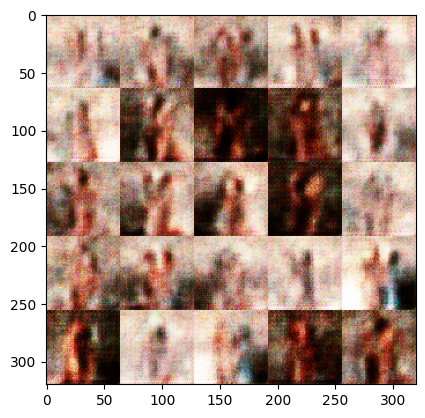

 40%|████      | 202/501 [08:06<12:12,  2.45s/it]

Epoch [201/501], d_loss: 0.7905585765838623, g_loss: 2.6956701278686523


 41%|████      | 203/501 [08:09<12:50,  2.58s/it]

Epoch [202/501], d_loss: 0.7040852308273315, g_loss: 1.083966612815857


 41%|████      | 204/501 [08:12<12:21,  2.50s/it]

...

Epoch [247/501], d_loss: 1.0300260782241821, g_loss: 2.232090473175049


 50%|████▉     | 249/501 [10:03<10:37,  2.53s/it]

Epoch [248/501], d_loss: 0.7454531192779541, g_loss: 1.6880927085876465


 50%|████▉     | 250/501 [10:05<10:21,  2.48s/it]

Epoch [249/501], d_loss: 1.1851688623428345, g_loss: 1.7017056941986084
Epoch [250/501], d_loss: 0.7873973846435547, g_loss: 3.4074018001556396


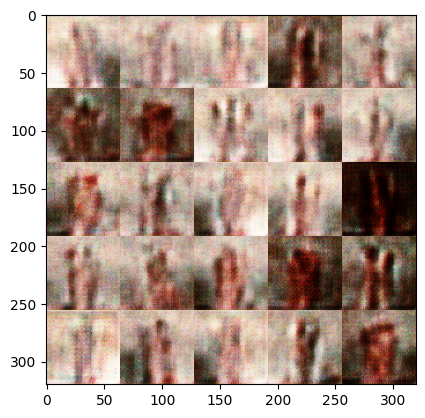

 50%|█████     | 252/501 [10:10<10:05,  2.43s/it]

Epoch [251/501], d_loss: 1.409034252166748, g_loss: 2.8504912853240967


 50%|█████     | 253/501 [10:13<09:50,  2.38s/it]

Epoch [252/501], d_loss: 0.8288466930389404, g_loss: 1.2037907838821411


 51%|█████     | 254/501 [10:15<10:25,  2.53s/it]

...

Epoch [297/501], d_loss: 0.8149188756942749, g_loss: 2.00527024269104


 60%|█████▉    | 299/501 [12:04<07:59,  2.37s/it]

Epoch [298/501], d_loss: 0.7091437578201294, g_loss: 1.4746767282485962


 60%|█████▉    | 300/501 [12:06<07:54,  2.36s/it]

Epoch [299/501], d_loss: 0.9031506776809692, g_loss: 2.522920608520508
Epoch [300/501], d_loss: 0.9450365900993347, g_loss: 2.057945728302002


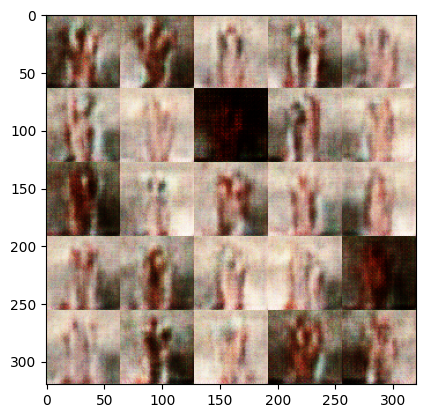

 60%|██████    | 302/501 [12:12<08:24,  2.53s/it]

Epoch [301/501], d_loss: 0.6894071102142334, g_loss: 1.9299049377441406


 60%|██████    | 303/501 [12:14<08:08,  2.47s/it]

Epoch [302/501], d_loss: 0.834260880947113, g_loss: 2.225463390350342


 61%|██████    | 304/501 [12:16<07:56,  2.42s/it]

...

Epoch [347/501], d_loss: 1.10848069190979, g_loss: 1.8926831483840942


 70%|██████▉   | 349/501 [14:06<06:13,  2.45s/it]

Epoch [348/501], d_loss: 0.7087768316268921, g_loss: 3.84592342376709


 70%|██████▉   | 350/501 [14:08<06:04,  2.41s/it]

Epoch [349/501], d_loss: 2.110790967941284, g_loss: 3.7699849605560303
Epoch [350/501], d_loss: 1.836782455444336, g_loss: 2.502230405807495


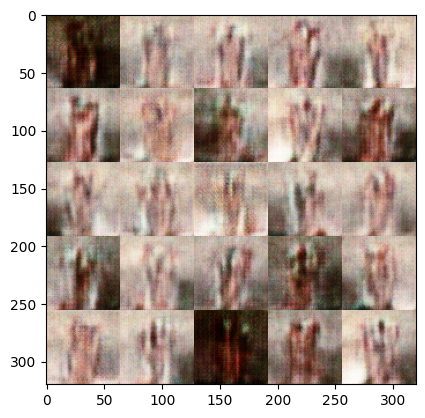

 70%|███████   | 352/501 [14:13<06:02,  2.43s/it]

Epoch [351/501], d_loss: 0.7271645069122314, g_loss: 0.9766618609428406


 70%|███████   | 353/501 [14:16<06:22,  2.58s/it]

Epoch [352/501], d_loss: 1.1285786628723145, g_loss: 1.5861384868621826


 71%|███████   | 354/501 [14:18<06:06,  2.49s/it]

...

Epoch [397/501], d_loss: 0.8432520627975464, g_loss: 2.3551886081695557


 80%|███████▉  | 399/501 [16:06<03:59,  2.34s/it]

Epoch [398/501], d_loss: 0.6925997734069824, g_loss: 0.8185480833053589


 80%|███████▉  | 400/501 [16:09<04:12,  2.50s/it]

Epoch [399/501], d_loss: 1.0923274755477905, g_loss: 1.7770044803619385
Epoch [400/501], d_loss: 0.7473888397216797, g_loss: 2.8118834495544434


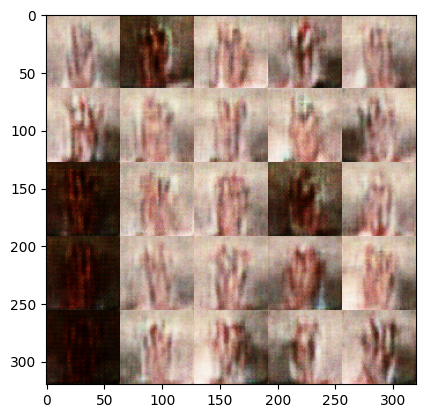

 80%|████████  | 402/501 [16:14<04:06,  2.49s/it]

Epoch [401/501], d_loss: 1.718858242034912, g_loss: 2.7541539669036865


 80%|████████  | 403/501 [16:17<03:58,  2.44s/it]

Epoch [402/501], d_loss: 1.2073241472244263, g_loss: 1.8214075565338135


 81%|████████  | 404/501 [16:19<03:51,  2.39s/it]

...

Epoch [447/501], d_loss: 0.6897592544555664, g_loss: 2.022819995880127


 90%|████████▉ | 449/501 [18:08<02:07,  2.45s/it]

Epoch [448/501], d_loss: 0.7213174104690552, g_loss: 2.7361977100372314


 90%|████████▉ | 450/501 [18:11<02:03,  2.41s/it]

Epoch [449/501], d_loss: 0.9585867524147034, g_loss: 2.4962401390075684
Epoch [450/501], d_loss: 0.6791076064109802, g_loss: 0.9698107242584229


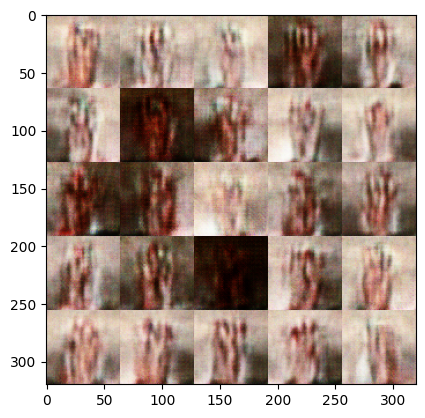

 90%|█████████ | 452/501 [18:16<02:08,  2.63s/it]

Epoch [451/501], d_loss: 1.1158607006072998, g_loss: 1.898238182067871


 90%|█████████ | 453/501 [18:19<02:01,  2.53s/it]

Epoch [452/501], d_loss: 0.7673828601837158, g_loss: 3.3189697265625


 91%|█████████ | 454/501 [18:21<01:55,  2.46s/it]

...

Epoch [497/501], d_loss: 0.7133978605270386, g_loss: 2.4227335453033447


100%|█████████▉| 499/501 [20:11<00:05,  2.53s/it]

Epoch [498/501], d_loss: 0.8320714235305786, g_loss: 1.8561885356903076


100%|█████████▉| 500/501 [20:13<00:02,  2.45s/it]

Epoch [499/501], d_loss: 0.7484958171844482, g_loss: 2.730245590209961
Epoch [500/501], d_loss: 0.8499959707260132, g_loss: 2.0548007488250732


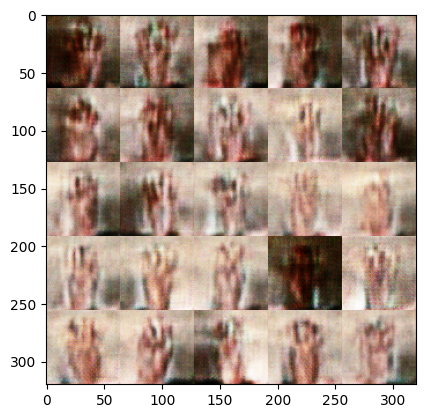

100%|██████████| 501/501 [20:16<00:00,  2.43s/it]


In [ ]:
generator = Generator()
discriminator = Discriminator()

g_loss_list, d_loss_list = train_gan(generator, discriminator, augmented_images, epochs=epochs, batch_size=batch_size)

学習結果を可視化します。

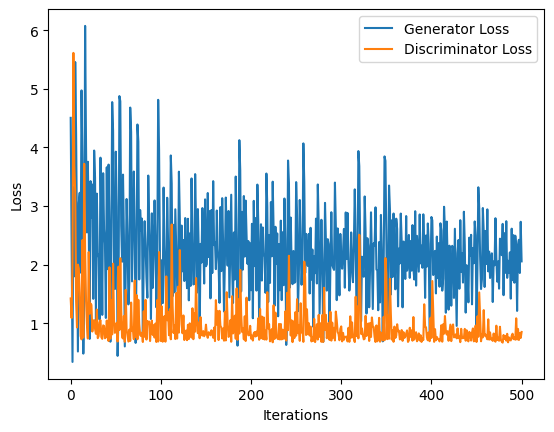

In [ ]:
plt.plot(g_loss_list, label='Generator Loss')
plt.plot(d_loss_list, label='Discriminator Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

学習データの確認

In [ ]:
!ls './gen_images'

gen_00000.png  gen_00100.png  gen_00200.png  gen_00300.png  gen_00400.png  gen_00500.png
gen_00050.png  gen_00150.png  gen_00250.png  gen_00350.png  gen_00450.png


生成された画像を確認

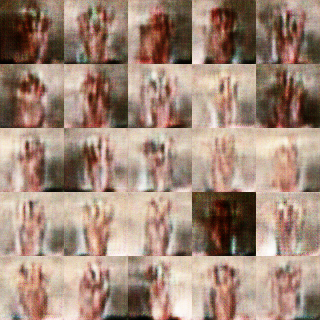

In [ ]:
from IPython.display import Image as IPImage
from IPython.display import display_png

display_png(IPImage('./gen_images/gen_00500.png'))

画像ファイルを圧縮してダウンロード

In [ ]:
!tar cvzf images.tar.gz ./gen_images

./gen_images/
./gen_images/gen_00400.png
./gen_images/gen_00500.png
./gen_images/gen_00350.png
./gen_images/gen_00300.png
./gen_images/gen_00150.png
./gen_images/gen_00200.png
./gen_images/gen_00050.png
./gen_images/gen_00250.png
./gen_images/gen_00000.png
./gen_images/gen_00100.png
./gen_images/gen_00450.png


In [ ]:
from google.colab import files
files.download('images.tar.gz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 参考リンク

### GANのネットワーク

- https://github.com/yoyoyo-yo/DeepLearningMugenKnock/blob/master/Scripts_Generative/scripts_keras/dcgan_keras.py
- https://github.com/jacobgil/keras-dcgan
- https://qiita.com/t-ae/items/236457c29ba85a7579d5
- https://arxiv.org/abs/1511.06434

### 乱数(Seed)固定
- https://scrapbox.io/nwtgck/Tensorflow+Keras%E3%81%A7%E5%86%8D%E7%8F%BE%E6%80%A7%E3%81%AE%E3%81%82%E3%82%8B%E4%B9%B1%E6%95%B0%E3%82%92%E7%94%9F%E6%88%90%E3%81%99%E3%82%8B_-_%E3%82%B7%E3%83%BC%E3%83%89%E5%9B%BA%E5%AE%9A
- https://qiita.com/okotaku/items/8d682a11d8f2370684c9